# Tutorial: Visualization engine basics

This notebook is both a visualization tutorial and a compact showcase of the current visualization surface:

1. build a tiny 2D box encoding through the canonical `encode(...)` workflow entrypoint,
2. reuse the same geometry for exact fibered visualizations,
3. build multiparameter-image objects through the canonical public constructors, and
4. save the resulting visuals from a notebook.

The notebook stays on the root public surface wherever that surface exists. The deliberate advanced exceptions are the raw box-fringe primitives used to define the tiny toy example and the exact fibered-arrangement construction in section 2.


Most later cells use the canonical public calls `TO.encode(...)`, `TO.available_visuals(...)`, `TO.visualize(...)`, `TO.save_visual(...)`, and `TO.save_visuals(...)`. The one advanced alias kept here is `TOA = TO.Advanced`, because the raw box-fringe primitives and the exact fibered-arrangement construction are not yet on the root surface.


In [1]:
global _TO_ROOT = let
    dir = abspath(pwd())
    root = nothing
    while true
        if isfile(joinpath(dir, "src", "TamerOp.jl"))
            root = dir
            break
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate repo root containing src/TamerOp.jl from pwd()=$(pwd()).")
        dir = parent
    end
    root
end

if isdefined(Main, :TamerOp)
    global TO = Base.invokelatest(getfield, Main, :TamerOp)
else
    try
        @eval Main using TamerOp
        global TO = Base.invokelatest(getfield, Main, :TamerOp)
    catch
        Base.include(Main, joinpath(_TO_ROOT, "src", "TamerOp.jl"))
        global TO = Base.invokelatest(getfield, Main, :TamerOp)
    end
end

for pkg in (:WGLMakie, :CairoMakie)
    try
        Base.require(Main, pkg)
    catch
    end
end

for backend in (:wglmakie, :cairomakie)
    try
        Base.invokelatest(TO.Visualization._try_load_visual_backend!, backend)
    catch
    end
end

global TOA = TO.Advanced

global DISPLAY_VIS_BACKEND = if TO.Visualization._visual_backend_available(:cairomakie)
    :cairomakie
elseif TO.Visualization._visual_backend_available(:wglmakie)
    :wglmakie
else
    :auto
end

global EXPORT_VIS_BACKEND = if TO.Visualization._visual_backend_available(:cairomakie)
    :cairomakie
elseif TO.Visualization._visual_backend_available(:wglmakie)
    :wglmakie
else
    :auto
end

println("Visualization backends loaded: ", collect(keys(TO.Visualization._VISUAL_RENDERERS)))
println("Notebook display backend: ", DISPLAY_VIS_BACKEND)
println("Notebook export backend: ", EXPORT_VIS_BACKEND)


Visualization backends loaded: [:wglmakie, :cairomakie]
Notebook display backend: cairomakie
Notebook export backend: cairomakie


## 1. Build a tiny 2D box encoding through `TO.encode(...)` and inspect its supported visuals

This first section is intentionally simple-surface-first: construct an `EncodingResult` through the canonical workflow entrypoint, inspect it through semantic accessors, ask which visuals exist, then render them with `TO.visualize(...)`. The tiny hand-built `BoxUpset` / `BoxDownset` inputs are the one owner-level exception in this section.

One contract detail matters here: `available_visuals(...)` lists supported visualization kinds, but some kinds are parameterized. In particular, `:query_overlay` requires a `point=` or `points=` keyword.


In [2]:
Ups = [
    TOA.BoxUpset([0.0, -10.0]),
    TOA.BoxUpset([1.0, -10.0]),
]
Downs = TOA.BoxDownset[]

enc = TO.encode(Ups, Downs)

P = TO.encoding_poset(enc)
pi = TO.encoding_map(enc)

(TO.result_summary(enc), TO.available_visuals(enc), TO.available_visuals(pi))


((kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.PLBackend.PLEncodingMapBoxes{2, 1, 0}, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :pl_backend, has_cohomology = true, has_presentation = true, module_dims = [0, 0, 0]), (:regions, :region_labels, :query_overlay), (:regions, :region_labels, :query_overlay))

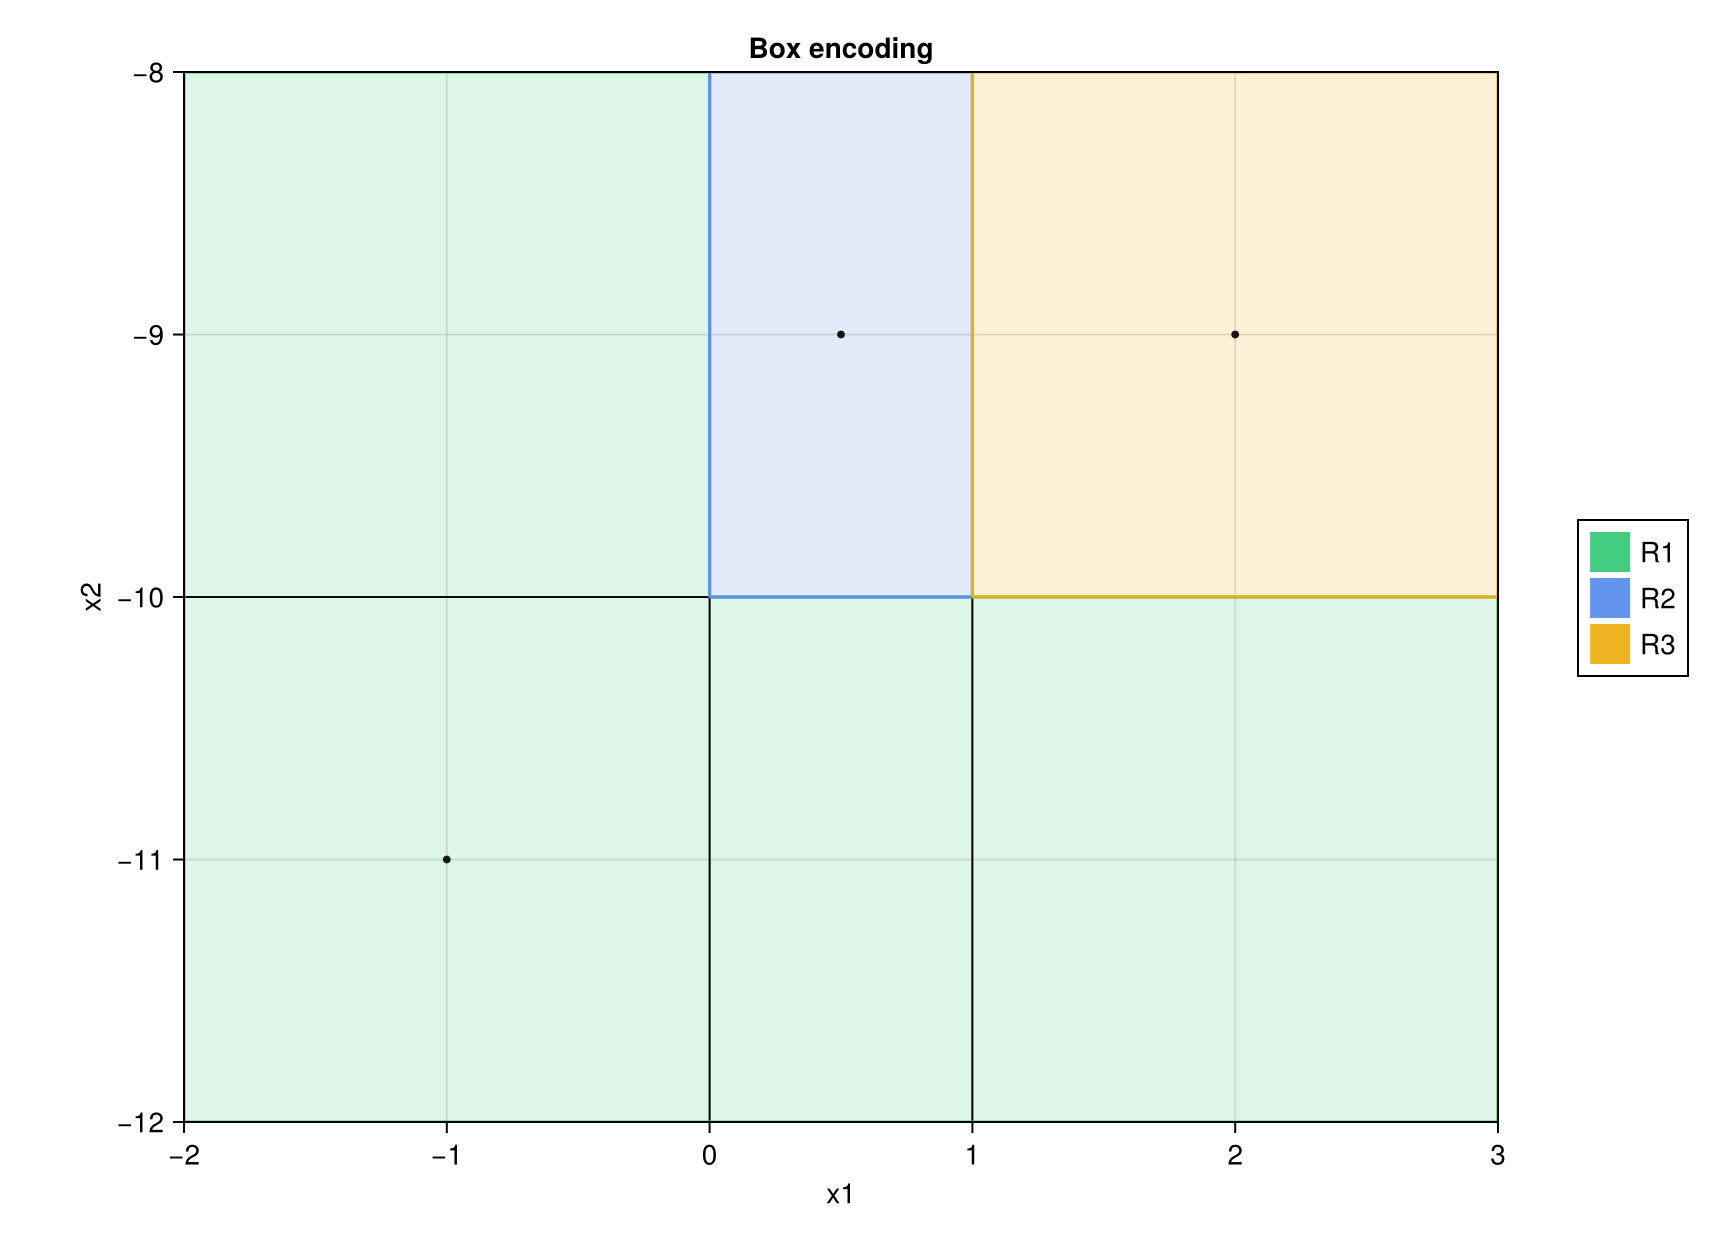

In [3]:
TO.visualize(pi; kind=:regions, backend=DISPLAY_VIS_BACKEND)

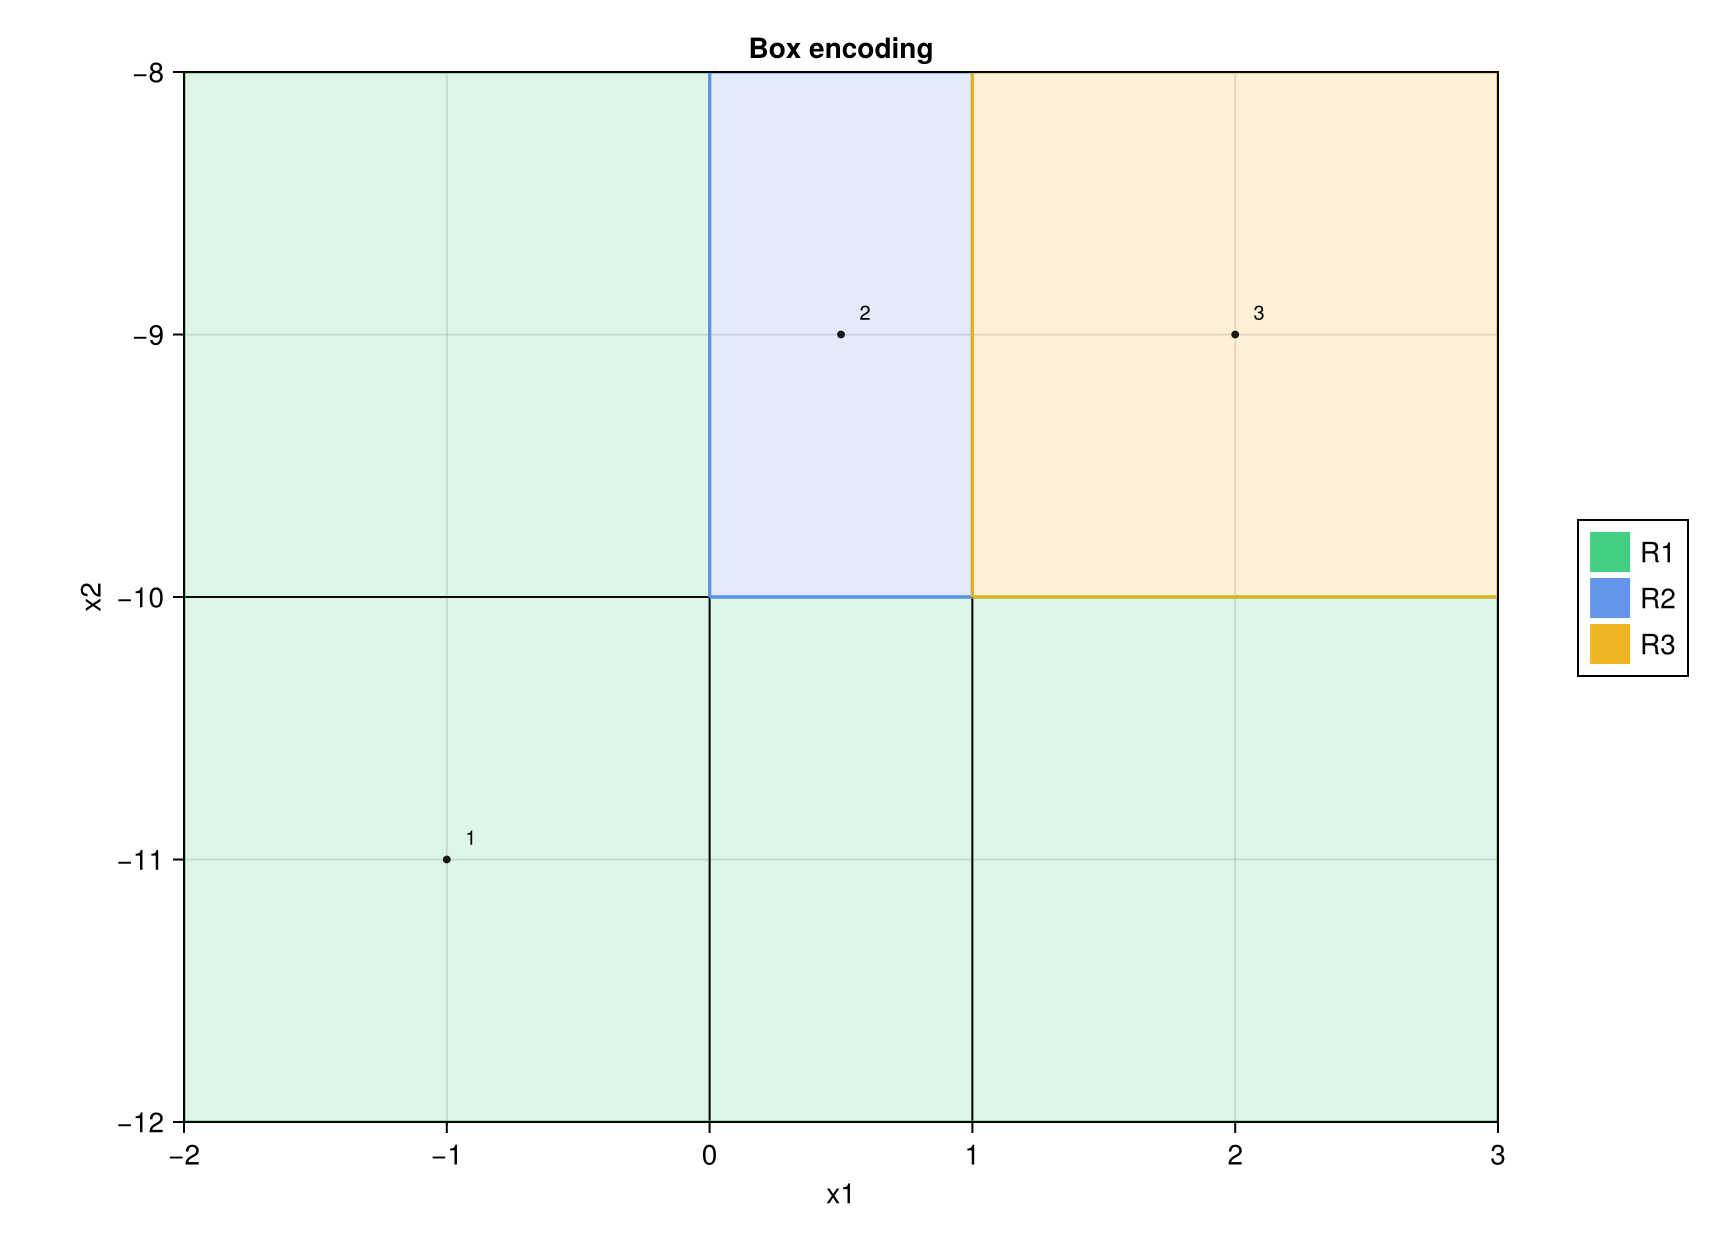

In [4]:
TO.visualize(pi; kind=:region_labels, backend=DISPLAY_VIS_BACKEND)


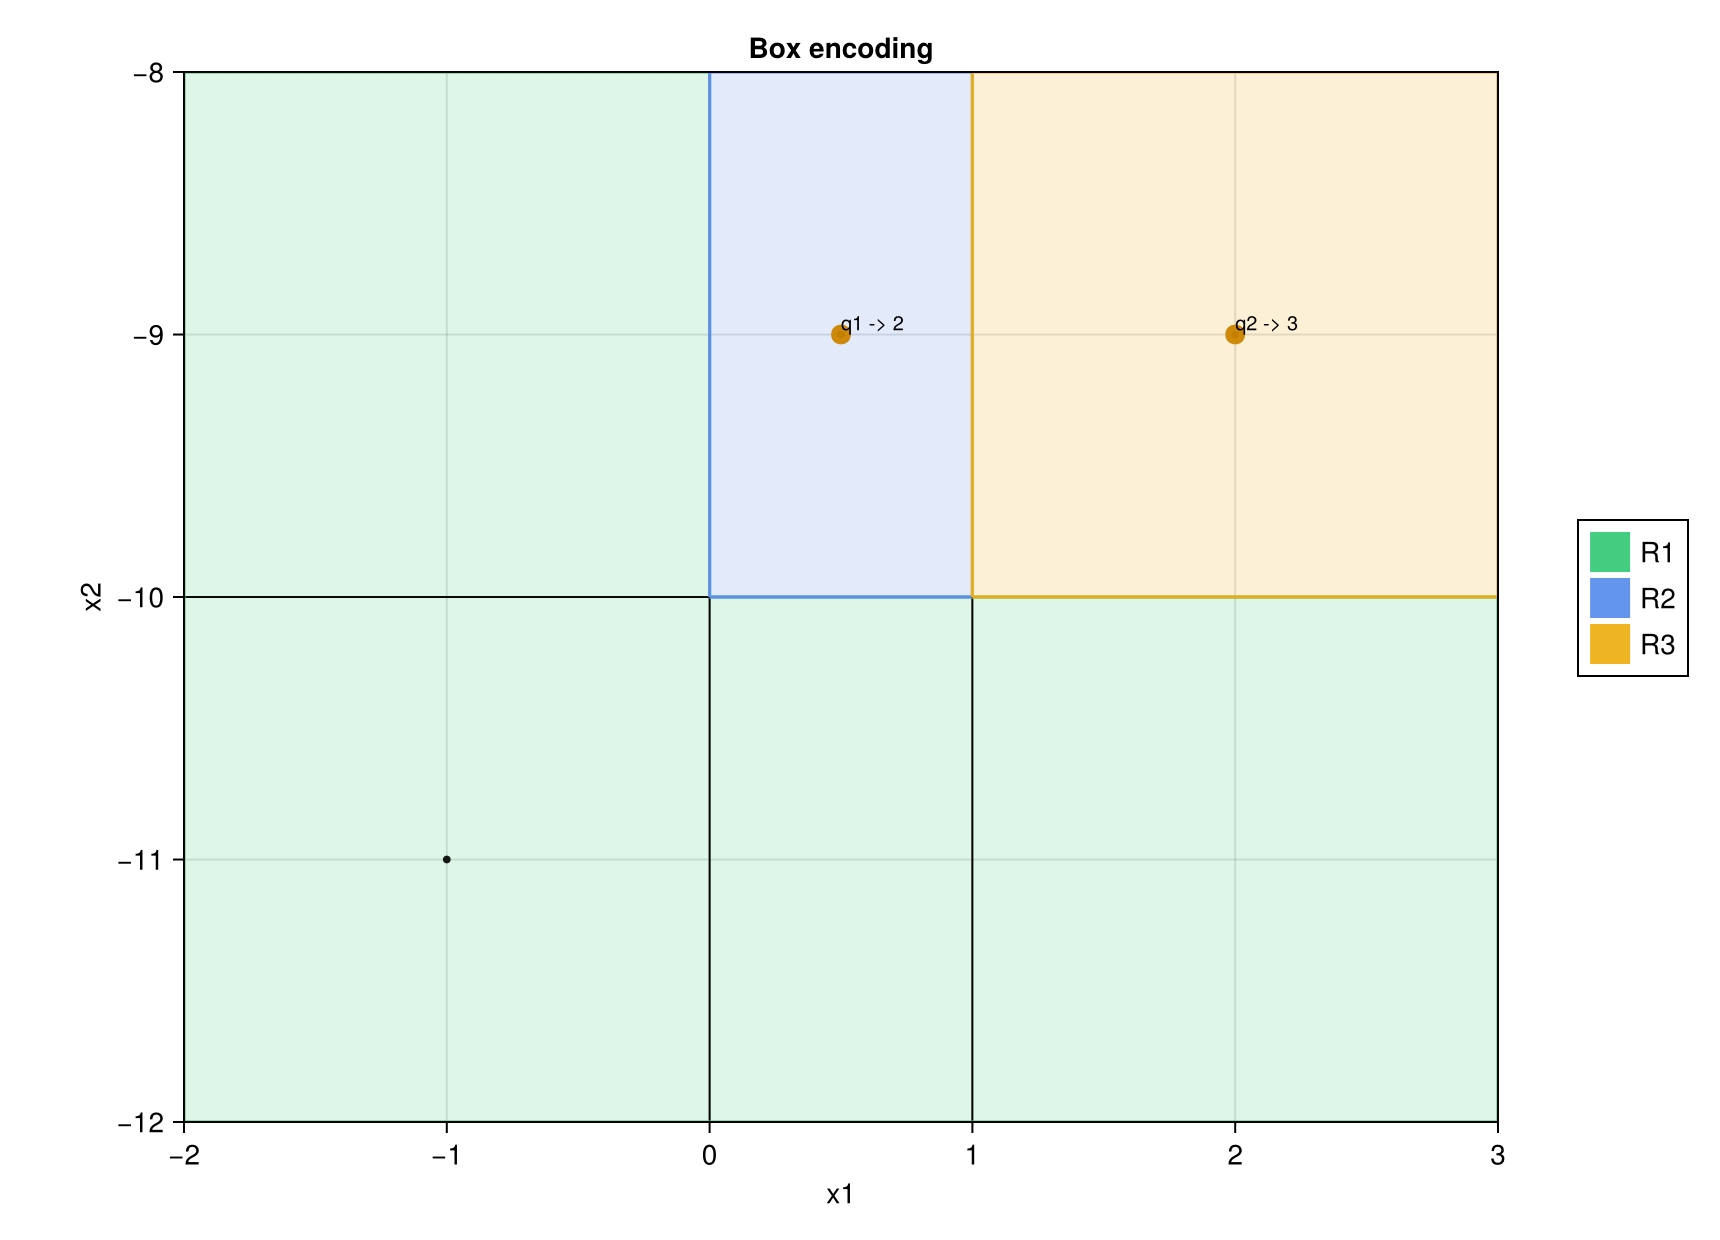

In [5]:
TO.visualize(
    pi;
    kind=:query_overlay,
    points=[(0.5, -9.0), (2.0, -9.0)],
    backend=DISPLAY_VIS_BACKEND,
)


## 2. Reuse the same geometry for exact fibered visualizations

This is the one section that still needs the advanced surface for exact arrangement construction. We build the exact arrangement object once, then stay on the canonical `TO.visualize(...)` path for the actual rendered views.


In [6]:
r_left = TOA.locate(pi, [0.5, 0.0])
r_right = TOA.locate(pi, [2.0, 0.0])

M_left = TOA.pmodule_from_fringe(
    TOA.one_by_one_fringe(
        P,
        TOA.principal_upset(P, r_left),
        TOA.principal_downset(P, r_right),
        1;
    ),
)

opts = TOA.InvariantOptions(box=([-1.0, -1.0], [2.0, 1.0]), strict=true)
arr = TOA.fibered_arrangement_2d(pi, opts; normalize_dirs=:L1, include_axes=true, precompute=:cells)

TO.available_visuals(arr)


(:fibered_arrangement, :fibered_query, :fibered_cell_highlight, :fibered_tie_break, :fibered_offset_intervals, :fibered_projected_comparison)

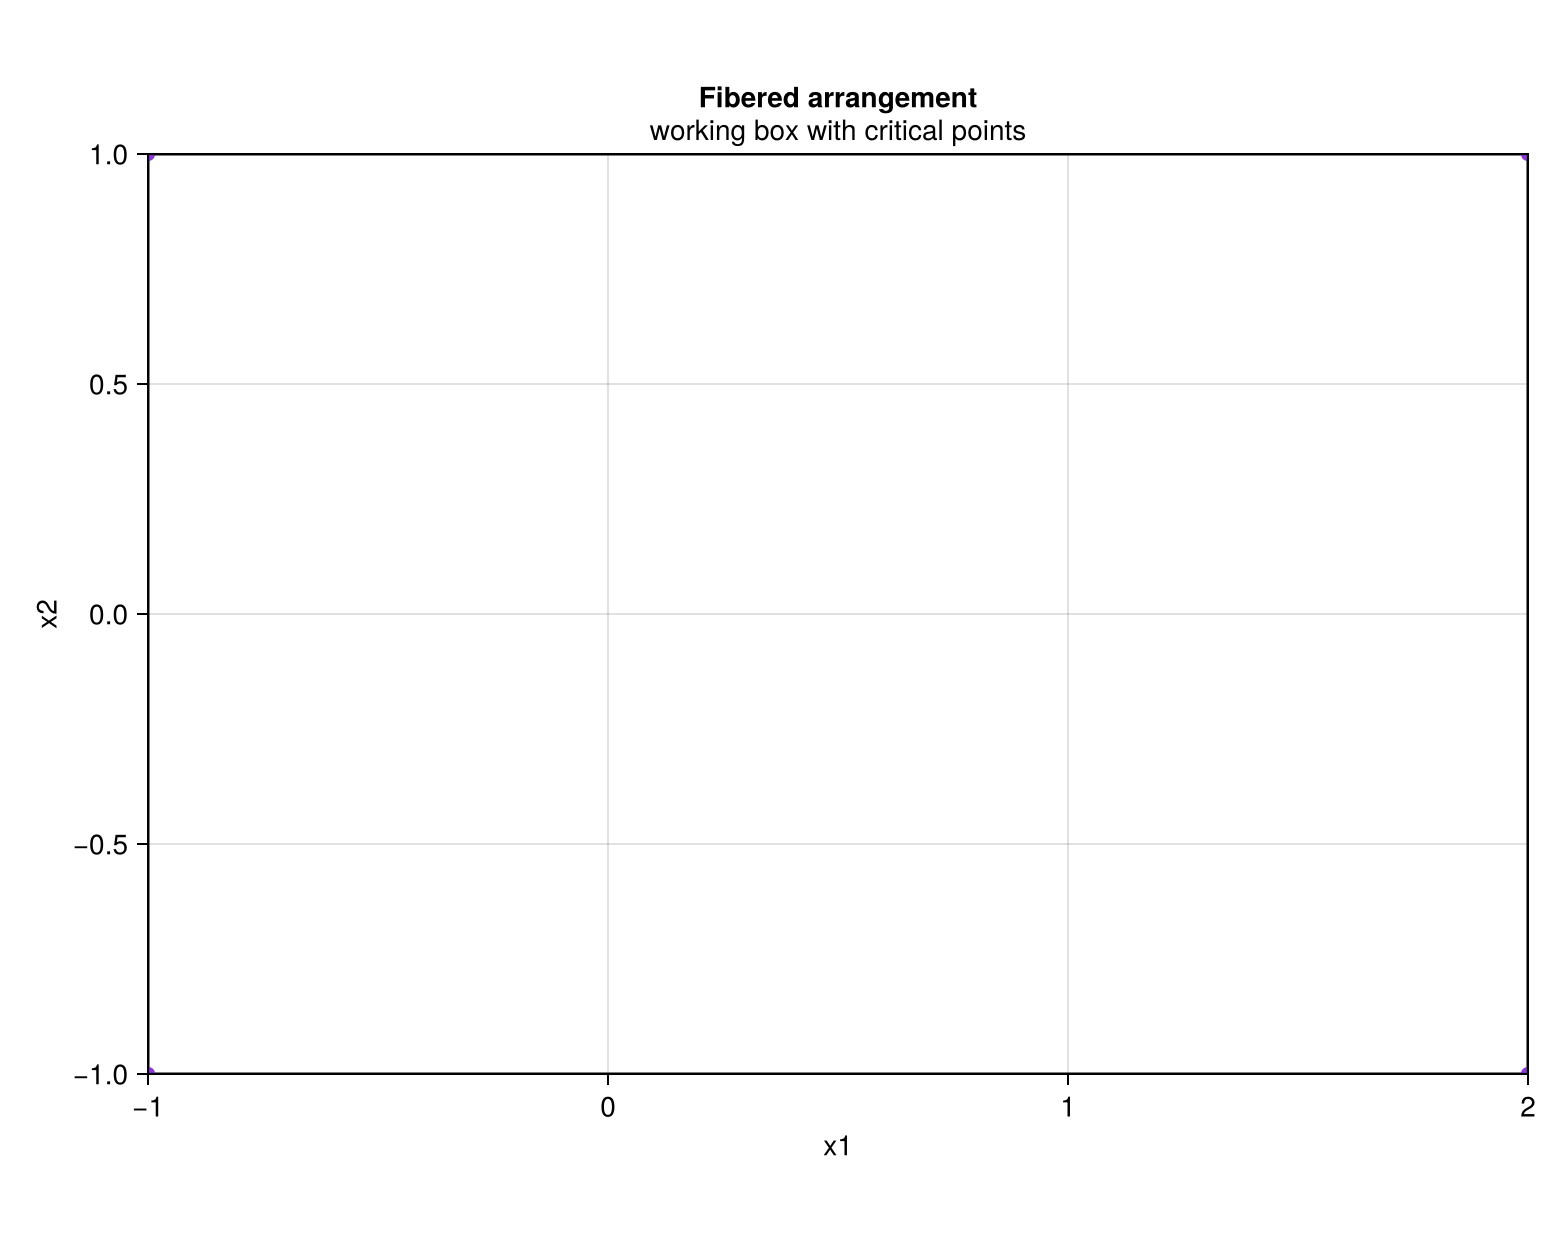

In [7]:
TO.visualize(arr; kind=:fibered_arrangement, backend=DISPLAY_VIS_BACKEND)


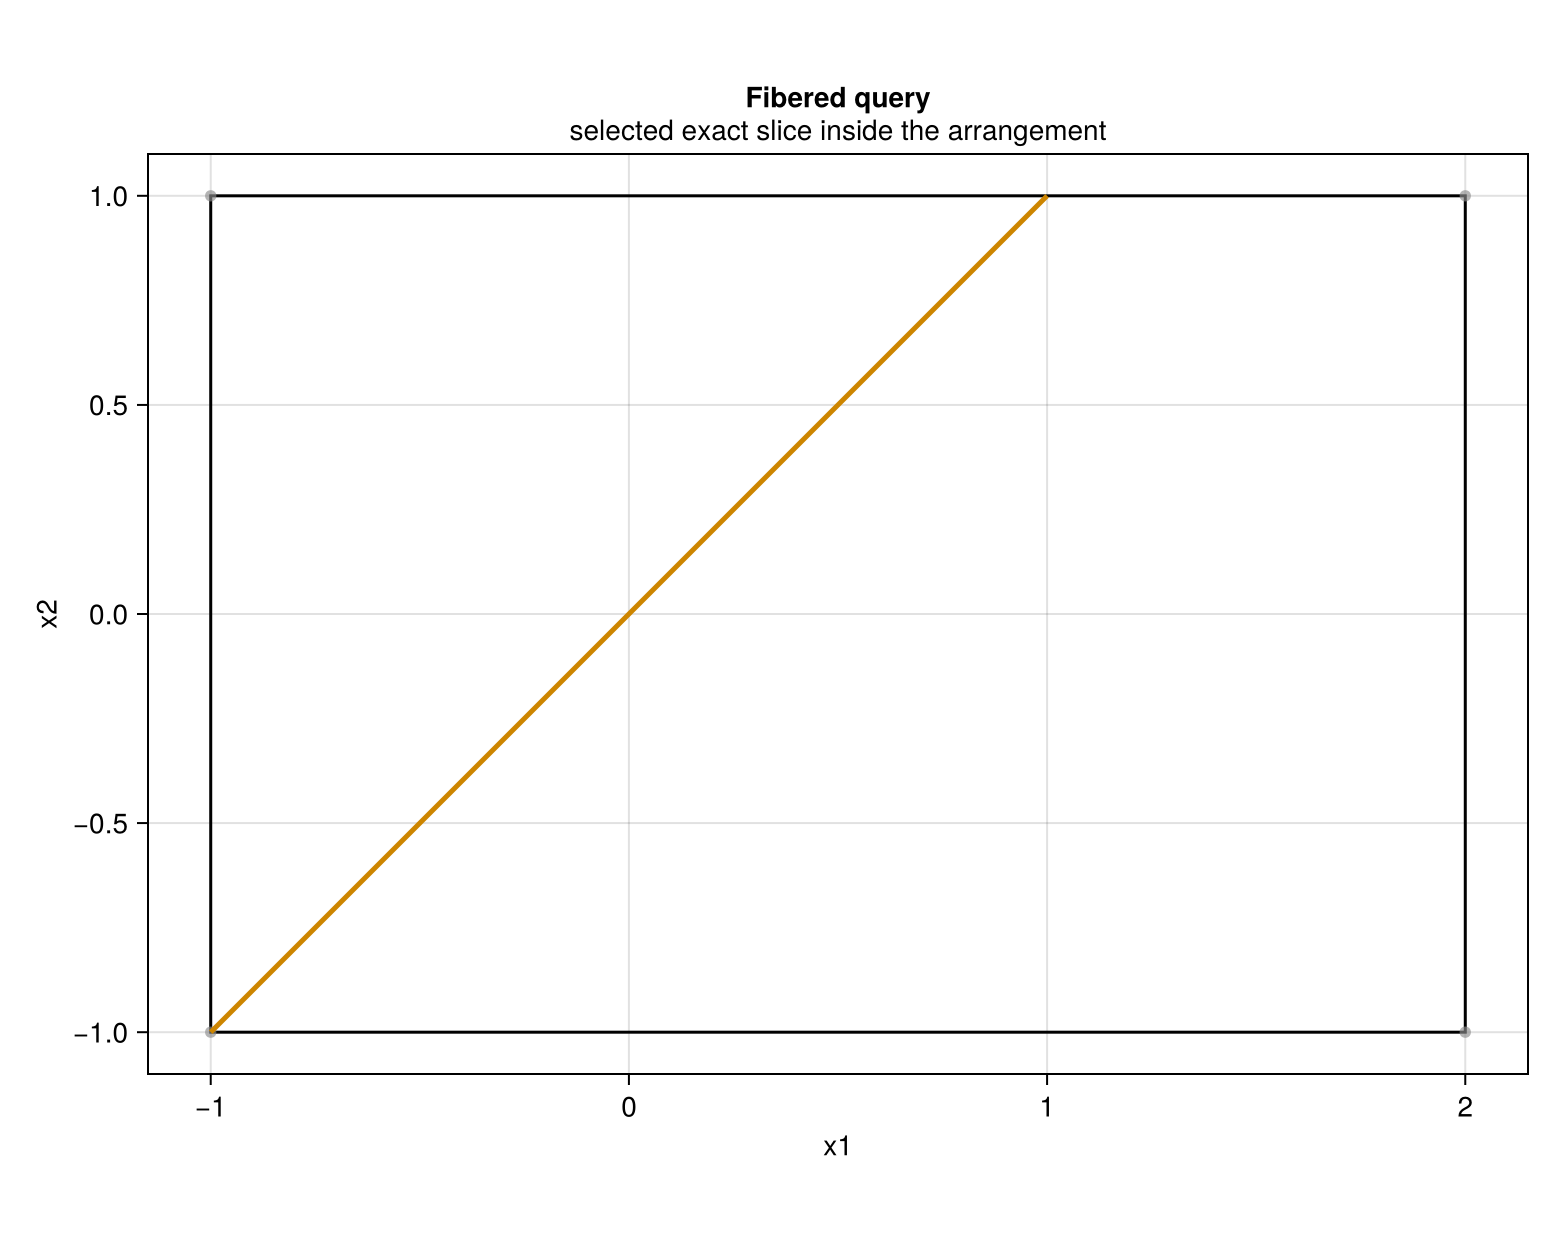

In [8]:
TO.visualize(arr; kind=:fibered_query, dir=(1.0, 1.0), offset=0.0, backend=DISPLAY_VIS_BACKEND)


## 3. Build MPPI decomposition, image, and sampled landscapes

This section returns to the root public surface. `mpp_decomposition`, `mpp_image`, and `mp_landscape` are the canonical user-facing constructors here, and visualization kinds attach to the object type you actually built.

For the landscape call here, the sampled slice family is given by directions together with basepoint offsets, so the notebook passes `offsets=[(0.0, 0.0)]` rather than a scalar normal offset.


In [9]:
decomp = TO.mpp_decomposition(M_left, pi; opts=opts, N=6, delta=:auto)
img = TO.mpp_image(M_left, pi; opts=opts, resolution=64, sigma=0.25, N=6, delta=:auto)
land = TO.mp_landscape(
    M_left,
    pi;
    opts=opts,
    directions=[(1.0, 1.0)],
    offsets=[(0.0, 0.0)],
    tgrid=collect(range(0.0, stop=1.5, length=24)),
    kmax=2,
)

(TO.available_visuals(decomp), TO.available_visuals(img), TO.available_visuals(land))


((:mpp_decomposition,), (:mpp_image,), (:mp_landscape, :landscape_slices))

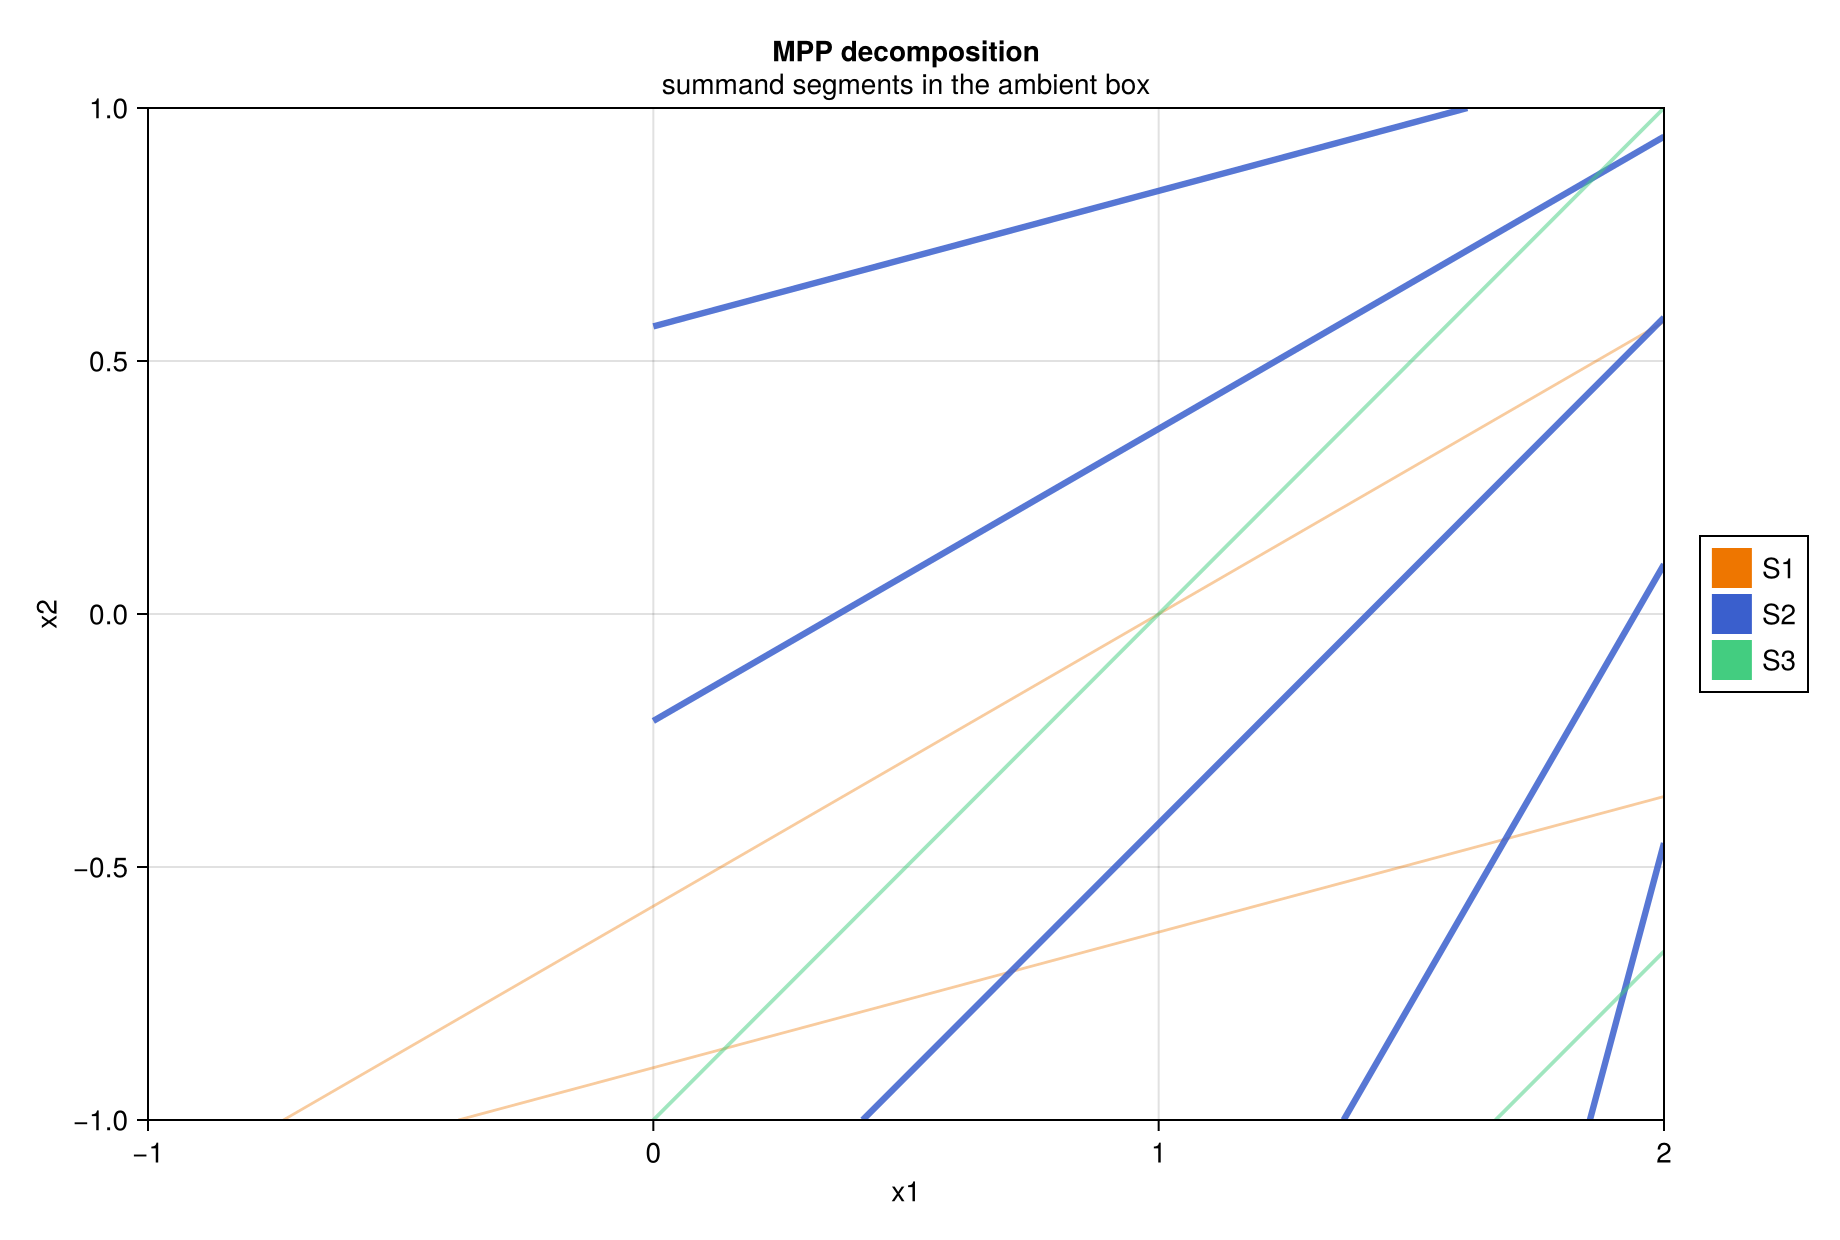

In [10]:
TO.visualize(decomp; kind=:mpp_decomposition, backend=DISPLAY_VIS_BACKEND)


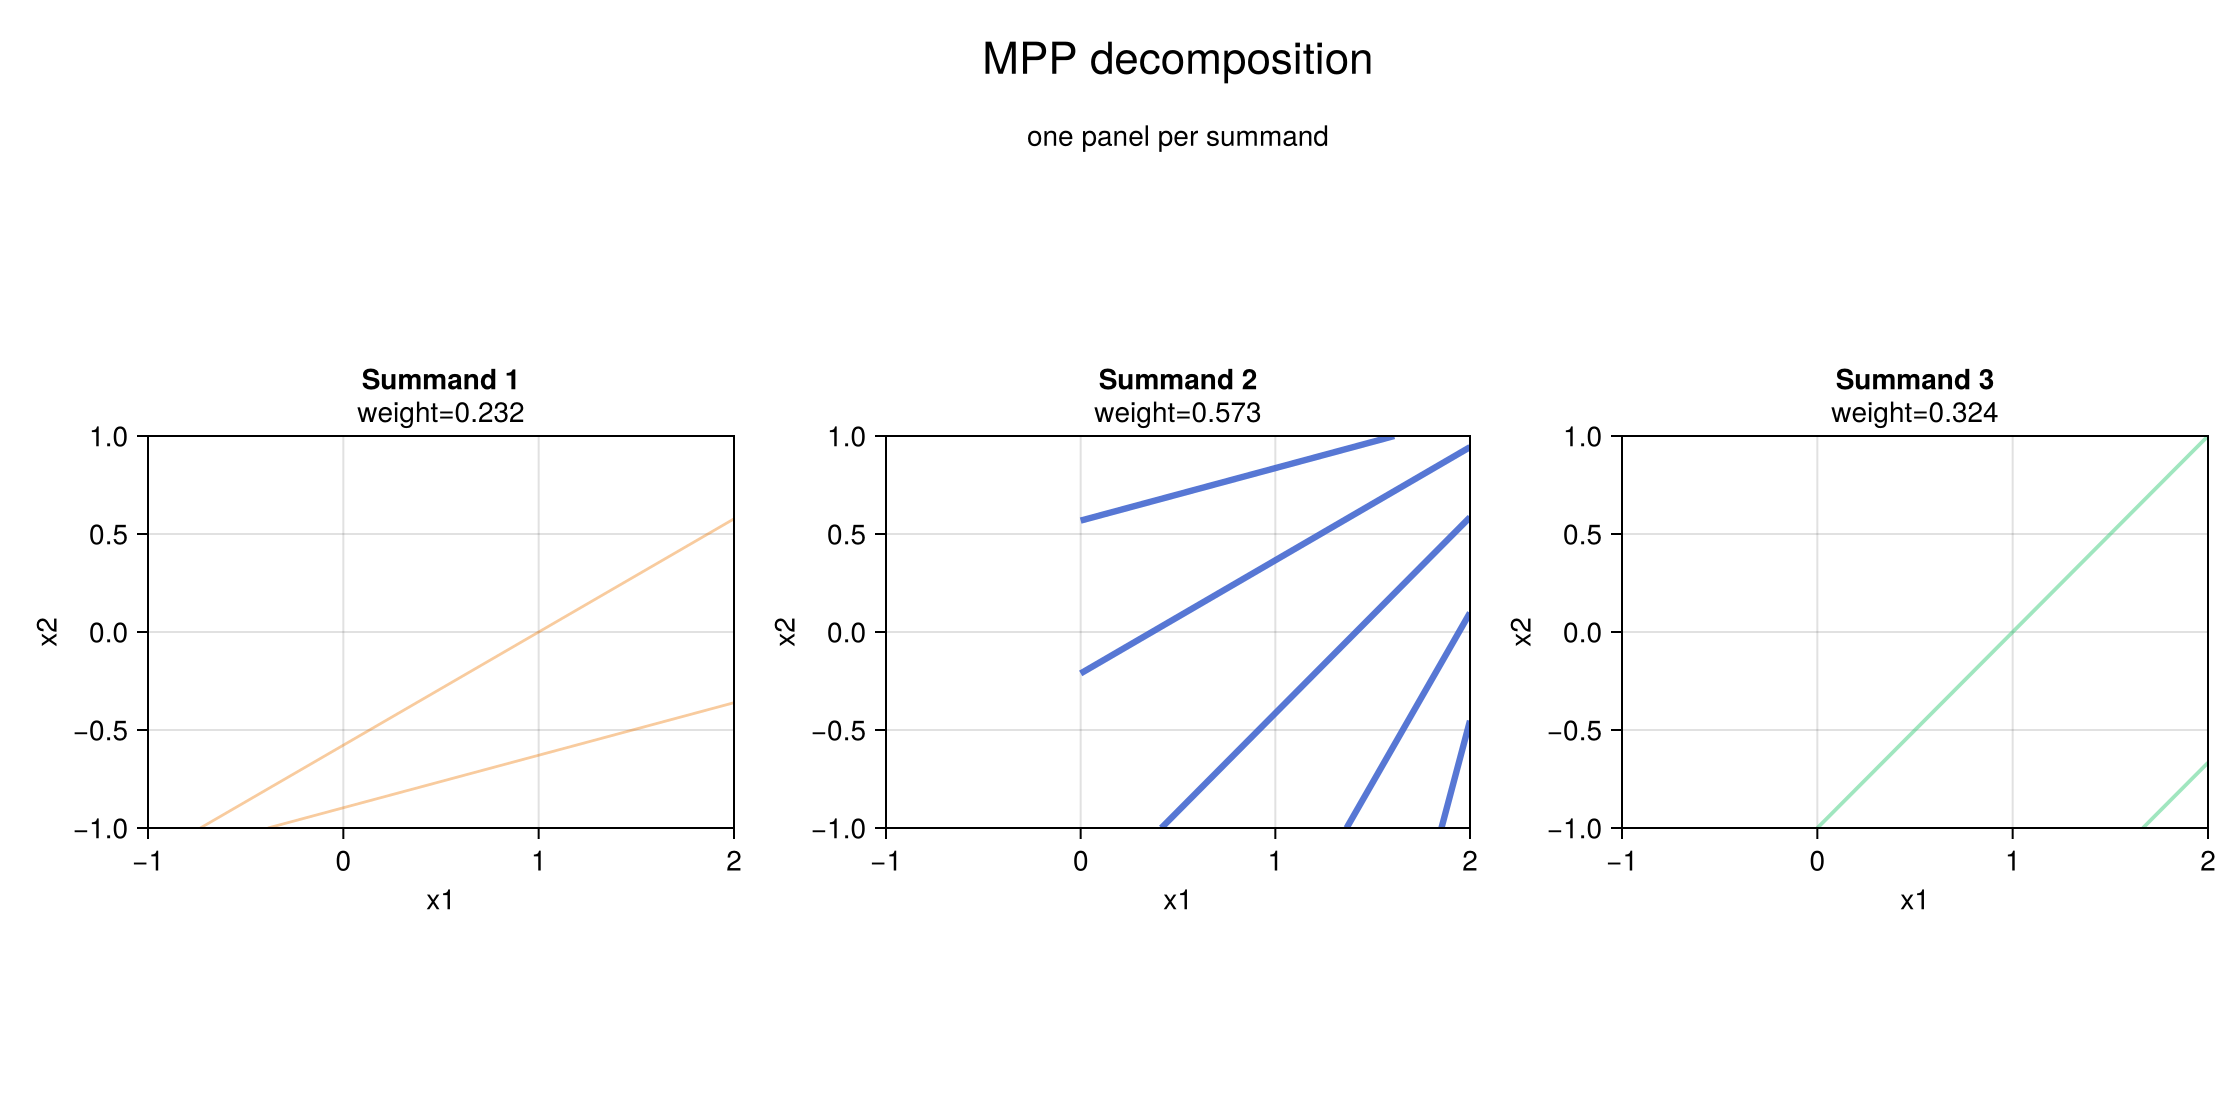

In [11]:
TO.visualize(decomp; kind=:mpp_decomposition, layout=:summands, backend=DISPLAY_VIS_BACKEND)


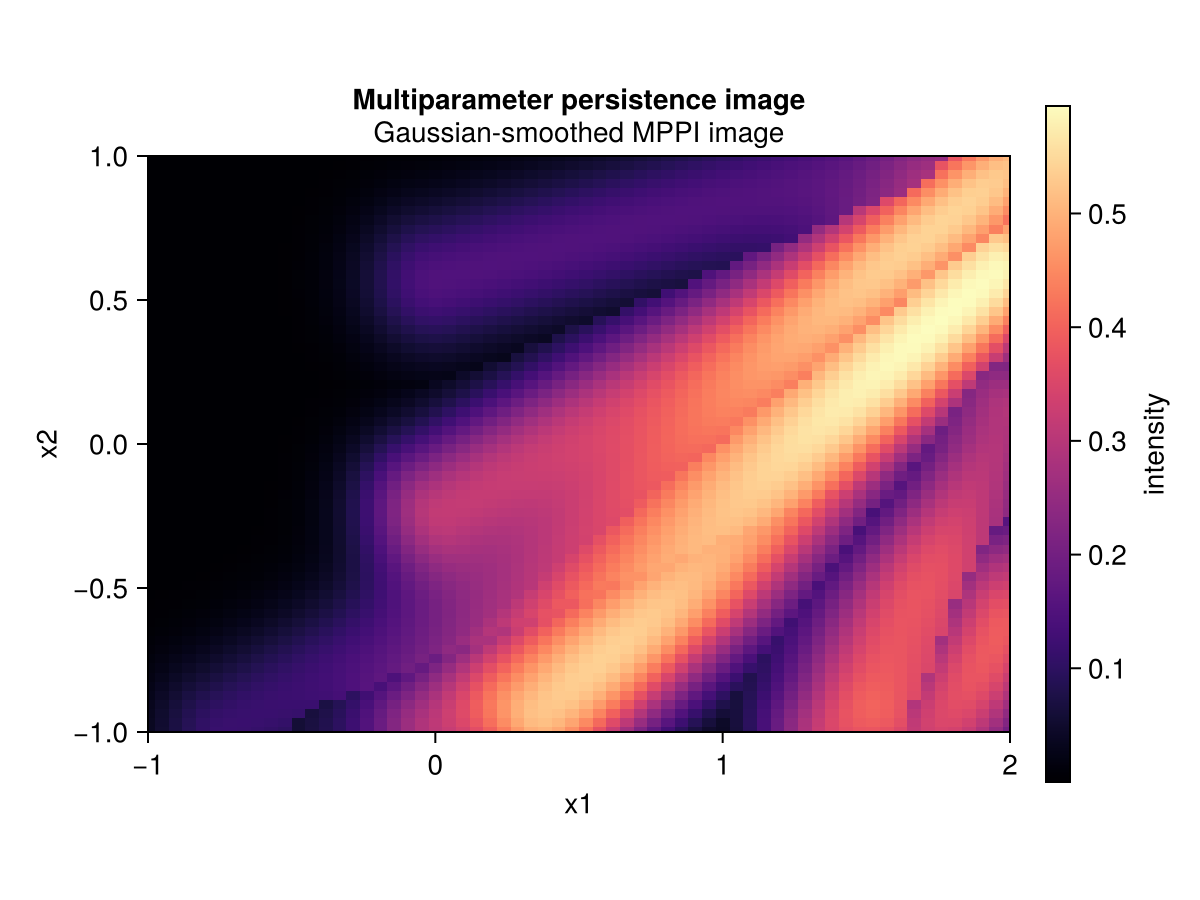

In [12]:
TO.visualize(img; kind=:mpp_image, backend=DISPLAY_VIS_BACKEND)


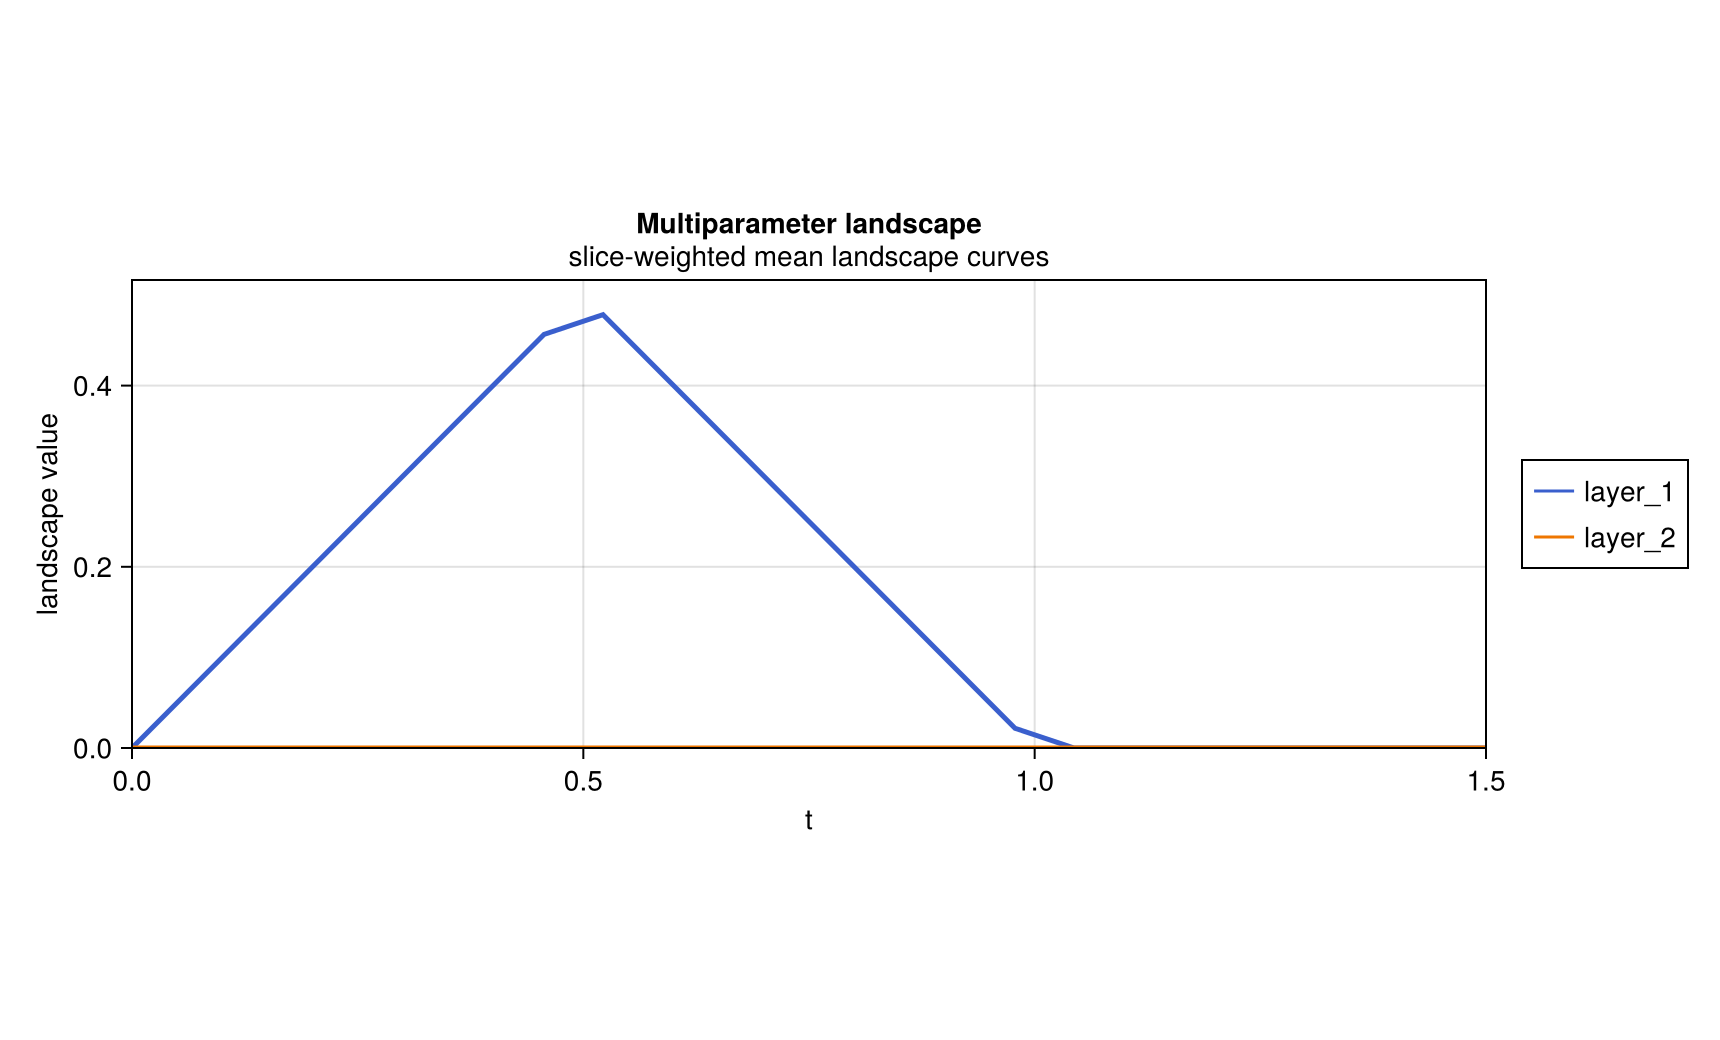

In [13]:
TO.visualize(land; kind=:mp_landscape, backend=DISPLAY_VIS_BACKEND)


## 4. Save the same visuals from a notebook

`save_visual(outdir, stem, obj)` and `save_visuals(outdir, requests)` are the canonical export paths. This notebook writes artifacts under `examples/_outputs/10_visualization_engine_basics/` and lets the library prefer deterministic PNG export via `CairoMakie` when it is available, falling back automatically to HTML only when needed. The exported encoding views include both standalone views and the parameterized query overlay.


In [14]:
outdir = joinpath(_TO_ROOT, "examples", "_outputs", "10_visualization_engine_basics")

exports = TO.save_visuals(outdir,
                          [
                              (; stem="encoding_regions", obj=pi, kind=:regions),
                              (; stem="encoding_region_labels", obj=pi, kind=:region_labels),
                              (; stem="encoding_query_overlay", obj=pi, kind=:query_overlay,
                                 points=[(0.5, -9.0), (2.0, -9.0)]),
                              (; stem="fibered_arrangement", obj=arr, kind=:fibered_arrangement),
                              (; stem="fibered_query_overlay", obj=arr, kind=:fibered_query,
                                 dir=(1.0, 1.0), offset=0.0),
                              (; stem="mpp_decomposition", obj=decomp, kind=:mpp_decomposition),
                              (; stem="mpp_decomposition_summands", obj=decomp, kind=:mpp_decomposition,
                                 layout=:summands),
                              (; stem="mpp_image", obj=img, kind=:mpp_image),
                              (; stem="mp_landscape", obj=land, kind=:mp_landscape),
                          ];
                          prefer=:static)

Dict(TO.export_stem(r) => TO.export_path(r) for r in exports)


Dict{String, String} with 9 entries:
  "mpp_decomposition_summands" => "/home/eriknovak/Documents/duke_fall_2025/tam…
  "mpp_image"                  => "/home/eriknovak/Documents/duke_fall_2025/tam…
  "encoding_regions"           => "/home/eriknovak/Documents/duke_fall_2025/tam…
  "encoding_region_labels"     => "/home/eriknovak/Documents/duke_fall_2025/tam…
  "encoding_query_overlay"     => "/home/eriknovak/Documents/duke_fall_2025/tam…
  "fibered_arrangement"        => "/home/eriknovak/Documents/duke_fall_2025/tam…
  "fibered_query_overlay"      => "/home/eriknovak/Documents/duke_fall_2025/tam…
  "mp_landscape"               => "/home/eriknovak/Documents/duke_fall_2025/tam…
  "mpp_decomposition"          => "/home/eriknovak/Documents/duke_fall_2025/tam…

## Notes

- This notebook is root-surface-first: the canonical calls are `encode(...)`, `available_visuals(...)`, `visualize(...)`, `save_visual(...)`, and `save_visuals(...)`.
- The raw box-fringe primitives in section 1 and the exact fibered-arrangement setup in section 2 are the deliberate `TO.Advanced` exceptions, because those typed objects are not yet on the root public surface.
- `available_visuals(obj)` tells you which visualization families an object supports, but some kinds are parameterized. For example, `:query_overlay` needs `point=` or `points=`.
- The inspectable spec layer is still available for advanced work, but it is intentionally omitted here to keep the notebook user-facing.
- Visualization kinds attach to object types, so `EncodingResult`, `MPPDecomposition`, `MPPImage`, and `MPLandscape` are visualized separately through their own supported views.
